In [1]:
from qiskit import __version__
print(__version__)

2.4.1


# Importing Packages

In [2]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector, state_fidelity, DensityMatrix, partial_trace
from qiskit_aer import AerSimulator
from qiskit_aer.library import SaveDensityMatrix, SaveStatevector
import numpy as np
from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, NullFormatter
import matplotlib.ticker as mticker
from matplotlib.patches import Rectangle
from matplotlib.gridspec import GridSpec
from multiprocessing import Pool
import importlib
import helpers
importlib.reload(helpers)
from helpers import encoding, ideal_syndrome_meas, ideal_recovery, logical_msd_all_errors, logical_msd_no_errors

# Defining Global Variable

In [3]:
theta = np.arctan(np.sqrt((np.sqrt(5) - 1) / 2))

# Graphing Settings

In [4]:
# --- APS-style global settings ---
mpl.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.size': 8,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'lines.linewidth': 1.2,
    'figure.dpi': 150,
})

# Qubit labeling of the Steane Code

Qubits are ordered from top to down, left to right, increasingly

The logical operators act on the left side of the triangle

# Infidelity to error rates

In [5]:
def inf_to_error(infidelity_list, num_qubits, infidelity_uncertainty_list=None):
    if infidelity_uncertainty_list is None:
        error_rates_list = []
        dimension = 2**num_qubits
        for infidelity in infidelity_list:
            error_rates_list.append( infidelity * (dimension / (dimension - 1)) )
        
        return error_rates_list
    else:
        error_rates_list = []
        error_uncertainty_list = []

        dimension = 2**num_qubits
        scale = dimension / (dimension - 1)

        for infidelity, uncertainty in zip(infidelity_list, infidelity_uncertainty_list):
            error_rates_list.append(scale * infidelity)
            error_uncertainty_list.append(scale * uncertainty)

        return error_rates_list, error_uncertainty_list

In [6]:
one_qubit_gate_infidelity = [2.8e-5 * i for i in range(1,6)]
two_qubit_gate_infidelity = [8.3e-4 * i for i in range(1,6)]
idle_gate_infidelity = [1.2e-4 * i for i in range(1,6)]
spam0 = [6.7e-4 * i for i in range(1,6)] # P(1|0), measured 1 given that 0 was prepared
spam1 = [1.2e-3 * i for i in range(1,6)] # P(0|1)

In [7]:
one_qubit_gate_error_prob = inf_to_error(one_qubit_gate_infidelity, num_qubits=1)
two_qubit_gate_error_prob = inf_to_error(two_qubit_gate_infidelity, num_qubits=2)
idle_gate_error_prob = inf_to_error(idle_gate_infidelity, num_qubits=1)

# Testing syndrome measurements and recovery

In [ ]:
# Prepare the ideal encoded magic state for comparison.
ideal = QuantumCircuit(7)
ideal.ry(theta, 0)
encoding(ideal, 0)
ideal_sv = Statevector.from_instruction(ideal)

# Create a 10-qubit circuit: 7 data qubits plus 3 syndrome ancillas.
test = QuantumCircuit(10)

# Classical registers for X- and Z-type syndrome outcomes.
x_syndrome = ClassicalRegister(3)
z_syndrome = ClassicalRegister(3)

test.add_register(x_syndrome, z_syndrome)

# Encode the input state into the Steane code.
encoding(test, 0)

# Insert test errors.
test.z(6)
test.x(4)

# Measure syndromes and apply the corresponding recovery operation.
ideal_syndrome_meas(test, 0, 7, x_syndrome, z_syndrome)
ideal_recovery(test, 0, x_syndrome, z_syndrome)

# Run a noiseless statevector simulation.
noise_model = NoiseModel()
meas_circuit_noise = test.copy()
meas_circuit_noise.append(
    SaveStatevector(
        num_qubits=10,
        label="state_post",
        conditional=True,
        pershot=True
    ),
    meas_circuit_noise.qubits
)

backend = AerSimulator(noise_model=noise_model)
job = backend.run(meas_circuit_noise, shots=1)
result = job.result()

# Print the saved statevectors grouped by syndrome outcome.
res_statevectors = result.data()['state_post']
print(res_statevectors)

{'0x14': [Statevector([ 0.35355339+0.j,  0.        +0.j,  0.        +0.j, ...,
             -0.        +0.j, -0.        +0.j, -0.        +0.j],
            dims=(2, 2, 2, 2, 2, 2, 2, 2, 2, 2))]}


In [ ]:
red_sv = partial_trace(res_statevectors['0x14'][0], list(range(7,10)))
print(state_fidelity(ideal_sv, red_sv))

0.9999999999999997


# Finding probability of success

In [ ]:
circuit = QuantumCircuit(21,14)

# Logical MSD circuit
for i in [0,7,14]:
    circuit.ry(theta, i)
encoding(circuit, 0)
encoding(circuit, 7)
encoding(circuit, 14)
 
for i in range(7):
    circuit.cz(i, i+7)
    circuit.h(i+14)

for i in range(7):
    circuit.cz(i+7, i+14)
    
for i in range(14):
    circuit.h(i)

In [ ]:
# Number of shots used to estimate the success probability.
shots = 1_000

# Run the circuit without additional noise.
noise_model = NoiseModel()
meas_circuit_noise = circuit.copy()

# Measure the 14 data qubits into the 14 classical bits.
meas_circuit_noise.measure([i for i in range(14)], [i for i in range(14)]) 

backend = AerSimulator(noise_model=noise_model)
job = backend.run(meas_circuit_noise, shots=shots)
result = job.result()

counts = result.get_counts()

# Count shots whose two Steane blocks have trivial syndrome
# and the expected logical parity.
correct = 0

for key, values in counts.items():
    # Split the measured bitstring into the two 7-qubit blocks.
    block1_syndrome = str(key)[0:7]
    block2_syndrome = str(key)[7:14]
    
    # Compute the three stabilizer parities and logical parity for block 1.
    block1_parity1 = (
        int(block1_syndrome[-1]) + int(block1_syndrome[-2])
        + int(block1_syndrome[-3]) + int(block1_syndrome[-4])
    ) % 2

    block1_parity2 = (
        int(block1_syndrome[-2]) + int(block1_syndrome[-3])
        + int(block1_syndrome[-5]) + int(block1_syndrome[-6])
    ) % 2

    block1_parity3 = (
        int(block1_syndrome[-3]) + int(block1_syndrome[-4])
        + int(block1_syndrome[-6]) + int(block1_syndrome[-7])
    ) % 2

    block1_logical_op = (
        int(block1_syndrome[-1]) + int(block1_syndrome[-2])
        + int(block1_syndrome[-5])
    ) % 2 
    
    # Compute the three stabilizer parities and logical parity for block 2.
    block2_parity1 = (
        int(block2_syndrome[-1]) + int(block2_syndrome[-2])
        + int(block2_syndrome[-3]) + int(block2_syndrome[-4])
    ) % 2

    block2_parity2 = (
        int(block2_syndrome[-2]) + int(block2_syndrome[-3])
        + int(block2_syndrome[-5]) + int(block2_syndrome[-6])
    ) % 2

    block2_parity3 = (
        int(block2_syndrome[-3]) + int(block2_syndrome[-4])
        + int(block2_syndrome[-6]) + int(block2_syndrome[-7])
    ) % 2

    block2_logical_op = (
        int(block2_syndrome[-1]) + int(block2_syndrome[-2])
        + int(block2_syndrome[-5])
    ) % 2
    
    # A shot is correct if both blocks have trivial stabilizer syndrome
    # and the expected logical parity.
    parity_list = [
        block1_parity1,
        block1_parity2,
        block1_parity3,
        block1_logical_op,
        block2_parity1,
        block2_parity2,
        block2_parity3,
        block2_logical_op
    ]

    if parity_list == [0, 0, 0, 0, 0, 0, 0, 0]:
        correct += values

print(f"Probability of measuring correct outputs: {correct / shots * 100}%")

Probability of measuring correct outputs: 41.4%


# Fidelity Simulations

Case: Logical MSD with all errors

In [63]:
# Initializing lists for later calculations of average fidelity and uncertainty for each error probability
# Also keeping track of total shots 
sum_fid_all_errors_list = np.zeros(5, dtype=float)
accepted_all_errors_list = np.zeros(5, dtype=float)
total_shots_all_errors = 0

In [ ]:
# Can be ran multiple times
# Dividing into smaller batches to ensure memory doesn't run out
num_shots = 50
batch_shots = 25

for p in range(len(spam0)):
    for _ in range(num_shots//batch_shots):
        sumfid, accepted = logical_msd_all_errors(batch_shots, one_qubit_gate_error_prob[p], two_qubit_gate_error_prob[p], spam0[p], spam1[p])
    
        sum_fid_all_errors_list[p] += sumfid
        accepted_all_errors_list[p] += accepted
    
total_shots_all_errors = total_shots_all_errors + num_shots

In [23]:
# Saving the results
np.savez("logical_msd_all_errors.npz",
    sum_fid_list=sum_fid_all_errors_list,
    accepted_list=accepted_all_errors_list,
    total_shots=total_shots_all_errors
)

In [24]:
# Calculating the average fidelity and uncertainty per physical error rate
avg_fid_all_errors_list = []
avg_fid_all_errors_unc_list = []
for i in range(len(spam0)):
    avg_fid = sum_fid_all_errors_list[i]/accepted_all_errors_list[i]
    avg_fid_unc = 1.96 * np.sqrt( (avg_fid)*(1 - avg_fid) / accepted_all_errors_list[i])
    avg_fid_all_errors_list.append(avg_fid)
    avg_fid_all_errors_unc_list.append(avg_fid_unc)

Case: Logical MSD with no errors

In [25]:
# Initializing lists for later calculations of average fidelity and uncertainty for each error probability
# Also keeping track of total shots 
sum_fid_no_errors_list = np.array([0]*5) 
accepted_no_errors_list = np.array([0]*5)
total_shots_no_errors = 0

In [ ]:
# Can be ran multiple times
num_shots = 50

for p in range(len(spam0)):
    sumfid, accepted = logical_msd_no_errors(num_shots, one_qubit_gate_error_prob[p])
    
    sum_fid_no_errors_list[p] += sumfid
    accepted_no_errors_list[p] += accepted

total_shots_no_errors = total_shots_no_errors + num_shots

In [27]:
# Saving the results
np.savez("logical_msd_no_errors.npz",
    sum_fid_list=sum_fid_no_errors_list,
    accepted_list=accepted_no_errors_list,
    total_shots=total_shots_no_errors
)

In [28]:
# Calculating the average fidelity and uncertainty per physical error rate
avg_fid_no_errors_list = []
avg_fid_no_errors_unc_list = []
for i in range(len(spam0)):
    avg_fid = sum_fid_no_errors_list[i]/accepted_no_errors_list[i]
    avg_fid_unc = 1.96 * np.sqrt( (avg_fid)*(1 - avg_fid) / accepted_no_errors_list[i])
    avg_fid_no_errors_list.append(avg_fid)
    avg_fid_no_errors_unc_list.append(avg_fid_unc)

Case: Input infidelities

In [19]:
ideal_input = QuantumCircuit(1)
ideal_input.ry(theta,0)
ideal_input_dm = DensityMatrix.from_instruction(ideal_input)

In [20]:
input_avg_fid_list = []
num_shots = 1

for i in range(len(one_qubit_gate_error_prob)):
    input_circuit = QuantumCircuit(1)
    input_circuit.ry(theta, 0) 
    
    nm = NoiseModel()
    nm.add_all_qubit_quantum_error(depolarizing_error(one_qubit_gate_error_prob[i], 1), ["ry"])
    
    input_circuit.append(SaveDensityMatrix(num_qubits=1, label='dm_post', conditional=True, pershot=True), input_circuit.qubits)
    
    backend = AerSimulator(noise_model=nm, method='density_matrix')
    job = backend.run(input_circuit, shots=num_shots)
    result = job.result()

    res_dm = result.data()['dm_post']
    
    input_avg_fid_list.append(state_fidelity(ideal_input_dm, res_dm[''][0]))

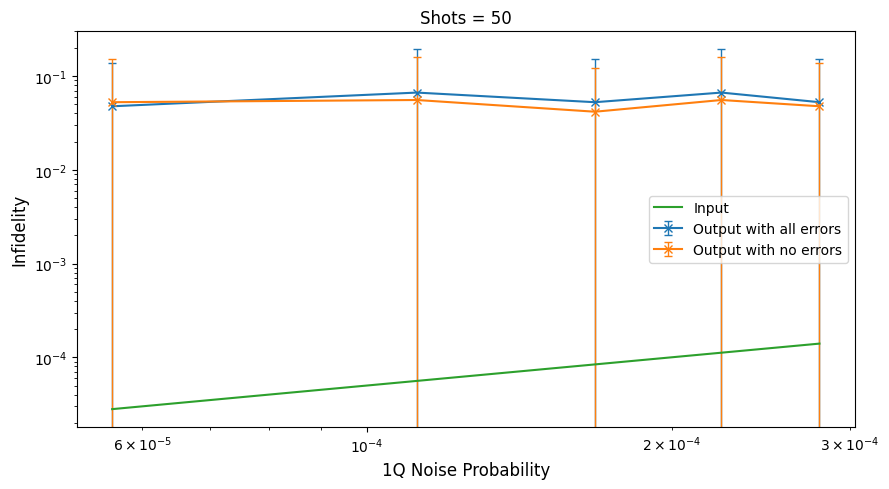

In [29]:
plt.figure(figsize=(9, 5))
plt.errorbar(
    one_qubit_gate_error_prob,
    [1-f for f in avg_fid_all_errors_list],
    yerr=avg_fid_all_errors_unc_list,
    fmt=f'x-',
    capsize=3,
    elinewidth=1,
    label='Output with all errors'
)
plt.errorbar(
    one_qubit_gate_error_prob,
    [1-f for f in avg_fid_no_errors_list],
    yerr=avg_fid_no_errors_unc_list,
    fmt=f'x-',
    capsize=3,
    elinewidth=1,
    label='Output with no errors'
)
plt.plot(one_qubit_gate_error_prob, [1-f for f in input_avg_fid_list], label='Input')

plt.xlabel("1Q Noise Probability", fontsize=12)
plt.ylabel("Infidelity", fontsize=12)
plt.yscale('log')
plt.xscale('log')
plt.title(f"Shots = {total_shots_all_errors}")
plt.tight_layout()
plt.legend()
plt.show()

# Loading data from cluster

In [8]:
data = np.load("cluster_logical_msd_all_errors.npz")
sum_fid_all_errors_list = data["sum_fid_list"]
accepted_all_errors_list = data["accepted_list"]
total_shots_all_errors = data["total_shots"].item()

data = np.load("cluster_logical_msd_no_errors.npz")
sum_fid_no_errors_list = data["sum_fid_list"]
accepted_no_errors_list = data["accepted_list"]
total_shots_no_errors = data["total_shots"].item()

data = np.load("cluster_logical_msd_meas_errors.npz")
sum_fid_meas_errors_list = data["sum_fid_list"]
accepted_meas_errors_list = data["accepted_list"]
total_shots_meas_errors = data["total_shots"].item()

data = np.load("cluster_logical_msd_2q_errors.npz")
sum_fid_2q_errors_list = data["sum_fid_list"]
accepted_2q_errors_list = data["accepted_list"]
total_shots_2q_errors = data["total_shots"].item()

data = np.load("cluster_logical_msd_1q_errors.npz")
sum_fid_1q_errors_list = data["sum_fid_list"]
accepted_1q_errors_list = data["accepted_list"]
total_shots_1q_errors = data["total_shots"].item()

In [9]:
print(total_shots_all_errors)
print(total_shots_no_errors)
print(total_shots_meas_errors)
print(total_shots_2q_errors)
print(total_shots_1q_errors)

220000
4200000
900000
200000
2100000


In [10]:
# Calculating the average fidelity and uncertainty per physical error rate
avg_fid_all_errors_list = []
avg_fid_all_errors_unc_list = []
for i in range(len(spam0)):
    avg_fid = sum_fid_all_errors_list[i]/accepted_all_errors_list[i]
    avg_fid_unc = 1.96 * np.sqrt( (avg_fid)*(1 - avg_fid) / accepted_all_errors_list[i])
    avg_fid_all_errors_list.append(avg_fid)
    avg_fid_all_errors_unc_list.append(avg_fid_unc)
    
avg_fid_no_errors_list = []
avg_fid_no_errors_unc_list = []
for i in range(len(spam0)):
    avg_fid = sum_fid_no_errors_list[i]/accepted_no_errors_list[i]
    avg_fid_unc = 1.96 * np.sqrt( (avg_fid)*(1 - avg_fid) / accepted_no_errors_list[i])
    avg_fid_no_errors_list.append(avg_fid)
    avg_fid_no_errors_unc_list.append(avg_fid_unc)
    
avg_fid_meas_errors_list = []
avg_fid_meas_errors_unc_list = []
for i in range(len(spam0)):
    avg_fid = sum_fid_meas_errors_list[i]/accepted_meas_errors_list[i]
    avg_fid_unc = 1.96 * np.sqrt( (avg_fid)*(1 - avg_fid) / accepted_meas_errors_list[i])
    avg_fid_meas_errors_list.append(avg_fid)
    avg_fid_meas_errors_unc_list.append(avg_fid_unc)
    
avg_fid_2q_errors_list = []
avg_fid_2q_errors_unc_list = []
for i in range(len(spam0)):
    avg_fid = sum_fid_2q_errors_list[i]/accepted_2q_errors_list[i]
    avg_fid_unc = 1.96 * np.sqrt( (avg_fid)*(1 - avg_fid) / accepted_2q_errors_list[i])
    avg_fid_2q_errors_list.append(avg_fid)
    avg_fid_2q_errors_unc_list.append(avg_fid_unc)
    
avg_fid_1q_errors_list = []
avg_fid_1q_errors_unc_list = []
for i in range(len(spam0)):
    avg_fid = sum_fid_1q_errors_list[i]/accepted_1q_errors_list[i]
    avg_fid_unc = 1.96 * np.sqrt( (avg_fid)*(1 - avg_fid) / accepted_1q_errors_list[i])
    avg_fid_1q_errors_list.append(avg_fid)
    avg_fid_1q_errors_unc_list.append(avg_fid_unc)

In [11]:
list1 = [1 - f for f in avg_fid_all_errors_list]
list2 = [1 - f for f in avg_fid_no_errors_list]
list3 = [1 - f for f in avg_fid_meas_errors_list]
list4 = [1 - f for f in avg_fid_2q_errors_list]
list5 = [1 - f for f in avg_fid_1q_errors_list]

all_output_error_rate, all_output_error_rate_unc = inf_to_error(list1, 1, avg_fid_all_errors_unc_list)
ideal_output_error_rate, ideal_output_error_rate_unc = inf_to_error(list2, 1, avg_fid_no_errors_unc_list)
meas_output_error_rate, meas_output_error_rate_unc = inf_to_error(list3, 1, avg_fid_meas_errors_unc_list)
two_q_output_error_rate, two_q_output_error_rate_unc = inf_to_error(list4, 1, avg_fid_2q_errors_unc_list)
one_q_output_error_rate, one_q_output_error_rate_unc = inf_to_error(list5, 1, avg_fid_1q_errors_unc_list)

# Calculating Infidelity Contributions

In [12]:
sum_c_list = []
for i in range(len(one_qubit_gate_error_prob)):
    sum_c_list.append(meas_output_error_rate[i] + two_q_output_error_rate[i] + one_q_output_error_rate[i])

one_qubit_contributions = 0
two_qubit_contributions = 0
measurement_contributions = 0
for i, e in enumerate(one_qubit_gate_error_prob):
    print(f"For 1Q error probability = {e}")
    print(f"1Q Fractions = {one_q_output_error_rate[i] / sum_c_list[i]}")
    print(f"2Q Fractions = {two_q_output_error_rate[i] / sum_c_list[i]}")
    print(f"Measurement Fractions = {meas_output_error_rate[i] / sum_c_list[i]}")
    print("")
    one_qubit_contributions += one_q_output_error_rate[i] / sum_c_list[i]
    two_qubit_contributions += two_q_output_error_rate[i] / sum_c_list[i]
    measurement_contributions += meas_output_error_rate[i] / sum_c_list[i]

one_qubit_contributions /= len(one_qubit_gate_error_prob)
two_qubit_contributions /= len(one_qubit_gate_error_prob)
measurement_contributions /= len(one_qubit_gate_error_prob)

For 1Q error probability = 5.6e-05
1Q Fractions = 0.036284344671432024
2Q Fractions = 0.8743017365325467
Measurement Fractions = 0.08941391879602129

For 1Q error probability = 0.000112
1Q Fractions = 0.04012585924407168
2Q Fractions = 0.8657423524202137
Measurement Fractions = 0.09413178833571464

For 1Q error probability = 0.000168
1Q Fractions = 0.052247240171138735
2Q Fractions = 0.80668045592995
Measurement Fractions = 0.14107230389891123

For 1Q error probability = 0.000224
1Q Fractions = 0.042349411554257595
2Q Fractions = 0.8378704767020896
Measurement Fractions = 0.11978011174365287

For 1Q error probability = 0.00028
1Q Fractions = 0.04628131302307415
2Q Fractions = 0.8354017534021114
Measurement Fractions = 0.11831693357481442



In [13]:
print(one_qubit_contributions)
print(two_qubit_contributions)
print(measurement_contributions)

0.043457633732794834
0.8439993549973822
0.11254301126982288


# Final Plot

Loading data from physical level

In [14]:
data = np.load("../physical_level/physical_level_component_analysis.npz")
optimal_infidelity = data["ideal_infidelity"]
optimal_output_error_rate = inf_to_error(optimal_infidelity, 1)

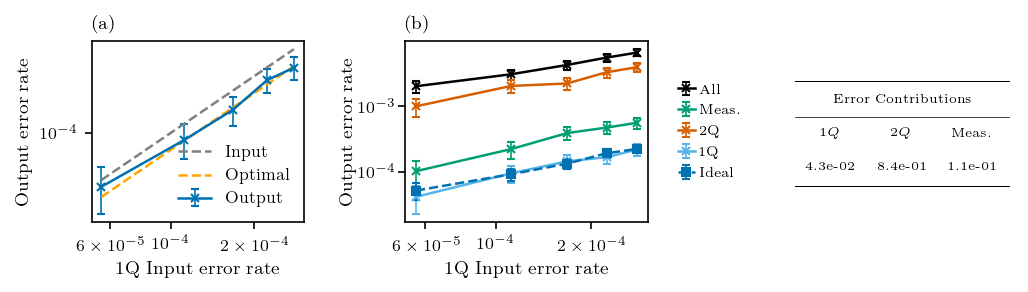

In [15]:
fig = plt.figure(figsize=(6.75, 1.8))

# Layout:
# plot 1 | spacer | plot 2 | legend | spacer | table
gs = GridSpec(
    1, 6,
    figure=fig,
    width_ratios=[1.0, 0.45, 1.15, 0.55, 0.08, 1.05],
    wspace=0.02
)

ax1 = fig.add_subplot(gs[0])
ax_spacer_12 = fig.add_subplot(gs[1])
ax2 = fig.add_subplot(gs[2])
ax_leg = fig.add_subplot(gs[3])
ax_spacer_lt = fig.add_subplot(gs[4])
ax_table = fig.add_subplot(gs[5])

ax_spacer_12.axis('off')
ax_spacer_lt.axis('off')
ax_leg.axis('off')
ax_table.axis('off')

# ── Plot 1 ───────────────────────────────────────────────
ax1.errorbar(
    one_qubit_gate_error_prob,
    ideal_output_error_rate,
    yerr=ideal_output_error_rate_unc,
    fmt='x',
    linestyle='-',
    capsize=2,
    elinewidth=0.8,
    color='#0072B2',
    markersize=4,
    label='Output'
)

ax1.plot(
    one_qubit_gate_error_prob,
    one_qubit_gate_error_prob,
    linestyle='--',
    color='gray',
    label='Input'
)

ax1.plot(
    one_qubit_gate_error_prob,
    optimal_output_error_rate,
    linestyle='--',
    color='orange',
    label='Optimal'
)

ax1.set_xscale('log')
ax1.set_yscale('log')

ax1.set_xticks([6e-5, 1e-4, 2e-4])
ax1.set_xticklabels([r'$6\times10^{-5}$', r'$10^{-4}$', r'$2\times10^{-4}$'])
ax1.xaxis.set_minor_locator(mticker.NullLocator())
ax1.xaxis.set_minor_formatter(mticker.NullFormatter())
ax1.yaxis.set_minor_locator(mticker.NullLocator())
ax1.yaxis.set_minor_formatter(mticker.NullFormatter())

ax1.legend(frameon=False, loc='lower right')
ax1.set_ylabel("Output error rate")
ax1.set_xlabel("1Q Input error rate")
ax1.set_title('(a)', loc='left', fontsize=9)

# ── Plot 2 ───────────────────────────────────────────────
series = [
    ('#000000', all_output_error_rate,  all_output_error_rate_unc),
    ('#009E73', meas_output_error_rate, meas_output_error_rate_unc),
    ('#D55E00', two_q_output_error_rate,   two_q_output_error_rate_unc),
    ('#56B4E9', one_q_output_error_rate,   one_q_output_error_rate_unc),
    ('#0072B2', ideal_output_error_rate,   ideal_output_error_rate_unc),
]

labels = [
    'All',
    'Meas.',
    '2Q',
    '1Q',
    'Ideal'
]

fmts = ['x', 'x', 'x', 'x', 's']
lss  = ['-', '-', '-', '-', '--']

for (color, y, yerr), label, fmt, ls in zip(series, labels, fmts, lss):
    ax2.errorbar(
        one_qubit_gate_error_prob,
        y,
        yerr=yerr,
        fmt=fmt,
        linestyle=ls,
        color=color,
        capsize=2,
        elinewidth=0.8,
        markersize=4,
        label=label
    )

ax2.set_xscale('log')
ax2.set_yscale('log')

ax2.set_xticks([6e-5, 1e-4, 2e-4])
ax2.set_xticklabels([r'$6\times10^{-5}$', r'$10^{-4}$', r'$2\times10^{-4}$'])
ax2.xaxis.set_minor_locator(mticker.NullLocator())
ax2.xaxis.set_minor_formatter(mticker.NullFormatter())
ax2.yaxis.set_minor_locator(mticker.NullLocator())
ax2.yaxis.set_minor_formatter(mticker.NullFormatter())

ax2.set_ylabel("Output error rate")
ax2.set_xlabel("1Q Input error rate")
ax2.set_title('(b)', loc='left', fontsize=9)

# Make plot 2 y-axis compact
ax2.yaxis.labelpad = 1
ax2.tick_params(axis='y', which='both', pad=1)

# ── Legend to the right of Plot 2 ─────────────────────────
handles, legend_labels = ax2.get_legend_handles_labels()

ax_leg.legend(
    handles,
    legend_labels,
    loc='center',
    frameon=False,
    fontsize=6.5,
    handlelength=1.2,
    handletextpad=0.35,
    labelspacing=0.65,
    borderaxespad=0.0
)

# ── Table to the right of the legend ──────────────────────
ax_table.axis('off')
ax_table.set_xlim(0, 1)
ax_table.set_ylim(0, 1)

headers = [r'$1Q$', r'$2Q$', r'Meas.']
values = [
    f'{one_qubit_contributions:.1e}',
    f'{two_qubit_contributions:.1e}',
    f'{measurement_contributions:.1e}'
]

# Table position inside ax_table
x0 = 0.02
y0 = 0.20
width = 0.96
height = 0.58

col_w = width / 3

# Row y-positions
y_title = y0 + 0.82 * height
y_header = y0 + 0.50 * height
y_values = y0 + 0.18 * height

# Horizontal rule positions
y_top = y0 + height
y_mid = y0 + 0.65 * height
y_bottom = y0

# Font sizes
fs_title = 6.2
fs_body = 5.8

# Title
ax_table.text(
    x0 + width / 2,
    y_title,
    'Error Contributions',
    ha='center',
    va='center',
    fontsize=fs_title,
    fontweight='semibold',
    transform=ax_table.transAxes
)

# Horizontal rules only
ax_table.plot(
    [x0, x0 + width],
    [y_top, y_top],
    color='black',
    linewidth=0.5,
    transform=ax_table.transAxes,
    clip_on=False
)

ax_table.plot(
    [x0, x0 + width],
    [y_mid, y_mid],
    color='black',
    linewidth=0.35,
    transform=ax_table.transAxes,
    clip_on=False
)

ax_table.plot(
    [x0, x0 + width],
    [y_bottom, y_bottom],
    color='black',
    linewidth=0.5,
    transform=ax_table.transAxes,
    clip_on=False
)

# Headers and values
for j, header in enumerate(headers):
    x = x0 + (j + 0.5) * col_w

    ax_table.text(
        x,
        y_header,
        header,
        ha='center',
        va='center',
        fontsize=fs_body,
        transform=ax_table.transAxes
    )

    ax_table.text(
        x,
        y_values,
        values[j],
        ha='center',
        va='center',
        fontsize=fs_body,
        transform=ax_table.transAxes
    )

# Compact APS-style margins
fig.subplots_adjust(
    left=0.08,
    right=0.99,
    bottom=0.23,
    top=0.90
)

plt.show()

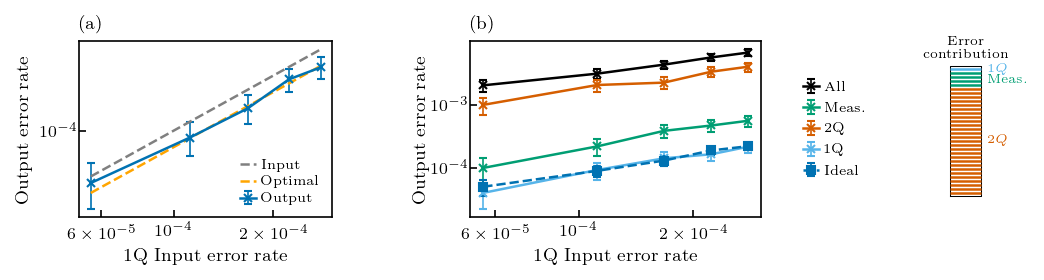

In [19]:
def draw_error_contribution_bar(
    ax_bar,
    values,
    colors,
    labels=None,
    total_lines=32,
    sort_by_size=True,
):
    """
    Draw a vertical barcode-style contribution bar.

    values: contribution magnitudes, e.g. [1Q, 2Q, Meas.]
    colors: colors corresponding to values
    labels: labels corresponding to values
    total_lines: total number of horizontal stripes in the bar
    """

    ax_bar.axis("off")
    ax_bar.set_xlim(0, 1)
    ax_bar.set_ylim(0, 1)

    values = np.asarray(values, dtype=float)
    values = np.maximum(values, 0)

    if labels is None:
        labels = [""] * len(values)

    if np.sum(values) == 0:
        return

    fractions = values / np.sum(values)

    raw_counts = fractions * total_lines
    counts = np.floor(raw_counts).astype(int)

    # Ensure every nonzero component gets at least one line
    for i, v in enumerate(values):
        if v > 0 and counts[i] == 0:
            counts[i] = 1

    # Fix rounding so counts sum to total_lines
    while np.sum(counts) < total_lines:
        residuals = raw_counts - counts
        counts[np.argmax(residuals)] += 1

    while np.sum(counts) > total_lines:
        removable = np.where(counts > 1)[0]
        if len(removable) == 0:
            break
        j = removable[np.argmax(counts[removable])]
        counts[j] -= 1

    if sort_by_size:
        order = np.argsort(-values)
    else:
        order = np.arange(len(values))

    # Bar geometry
    # Thicker bar, with room on the right for labels
    x_left = 0.28
    x_right = 0.72
    y_bottom = 0.12
    y_top = 0.86

    # Outline
    ax_bar.plot(
        [x_left, x_right, x_right, x_left, x_left],
        [y_bottom, y_bottom, y_top, y_top, y_bottom],
        color="black",
        linewidth=0.5,
        transform=ax_bar.transAxes,
        clip_on=False,
    )

    y_positions = np.linspace(y_bottom + 0.02, y_top - 0.02, total_lines)

    k = 0
    segment_centers = []

    for idx in order:
        start_k = k

        for _ in range(counts[idx]):
            if k >= total_lines:
                break

            ax_bar.hlines(
                y_positions[k],
                x_left,
                x_right,
                colors=colors[idx],
                linewidth=1.2,
                transform=ax_bar.transAxes,
                clip_on=False,
            )
            k += 1

        end_k = k - 1

        if end_k >= start_k:
            y_center = 0.5 * (y_positions[start_k] + y_positions[end_k])
            segment_centers.append((idx, y_center))

    # Title
    ax_bar.text(
        0.50,
        0.96,
        "Error\ncontribution",
        ha="center",
        va="center",
        fontsize=6.2,
        transform=ax_bar.transAxes,
    )

    # Labels placed farther to the right of the bar
    for idx, y_center in segment_centers:
        ax_bar.text(
            0.82,
            y_center,
            labels[idx],
            ha="left",
            va="center",
            fontsize=5.8,
            color=colors[idx],
            transform=ax_bar.transAxes
        )


fig = plt.figure(figsize=(6.75, 1.75))

# Layout:
# plot 1 | spacer | plot 2 | legend | spacer | contribution bar
gs = GridSpec(
    1,
    6,
    figure=fig,
    width_ratios=[1.0, 0.52, 1.15, 0.55, 0.08, 0.28],
    wspace=0.02,
)

ax1 = fig.add_subplot(gs[0])
ax_spacer_12 = fig.add_subplot(gs[1])
ax2 = fig.add_subplot(gs[2])
ax_leg = fig.add_subplot(gs[3])
ax_spacer_lt = fig.add_subplot(gs[4])
ax_bar = fig.add_subplot(gs[5])

ax_spacer_12.axis("off")
ax_spacer_lt.axis("off")
ax_leg.axis("off")
ax_bar.axis("off")


# ── Plot 1 ───────────────────────────────────────────────
ax1.errorbar(
    one_qubit_gate_error_prob,
    ideal_output_error_rate,
    yerr=ideal_output_error_rate_unc,
    fmt="x",
    linestyle="-",
    capsize=2,
    elinewidth=0.8,
    color="#0072B2",
    markersize=4,
    label="Output",
)

ax1.plot(
    one_qubit_gate_error_prob,
    one_qubit_gate_error_prob,
    linestyle="--",
    color="gray",
    label="Input",
)

ax1.plot(
    one_qubit_gate_error_prob,
    optimal_output_error_rate,
    linestyle="--",
    color="orange",
    label="Optimal",
)

ax1.set_xscale("log")
ax1.set_yscale("log")

ax1.set_xticks([6e-5, 1e-4, 2e-4])
ax1.set_xticklabels(
    [r"$6\times10^{-5}$", r"$10^{-4}$", r"$2\times10^{-4}$"]
)

ax1.xaxis.set_minor_locator(mticker.NullLocator())
ax1.xaxis.set_minor_formatter(mticker.NullFormatter())
ax1.yaxis.set_minor_locator(mticker.NullLocator())
ax1.yaxis.set_minor_formatter(mticker.NullFormatter())

ax1.tick_params(which="both", direction="in", top=False, right=False)
ax1.tick_params(axis="y", which="both", pad=1)

ax1.legend(
    frameon=False,
    loc="lower right",
    fontsize=6.5,
    handlelength=1.2,
    handletextpad=0.35,
    labelspacing=0.35,
)

ax1.set_ylabel("Output error rate")
ax1.set_xlabel("1Q Input error rate")
ax1.set_title("(a)", loc="left", fontsize=9)


# ── Plot 2 ───────────────────────────────────────────────
series = [
    ("#000000", all_output_error_rate, all_output_error_rate_unc),
    ("#009E73", meas_output_error_rate, meas_output_error_rate_unc),
    ("#D55E00", two_q_output_error_rate, two_q_output_error_rate_unc),
    ("#56B4E9", one_q_output_error_rate, one_q_output_error_rate_unc),
    ("#0072B2", ideal_output_error_rate, ideal_output_error_rate_unc),
]

labels = [
    "All",
    "Meas.",
    "2Q",
    "1Q",
    "Ideal",
]

fmts = ["x", "x", "x", "x", "s"]
lss = ["-", "-", "-", "-", "--"]

for (color, y, yerr), label, fmt, ls in zip(series, labels, fmts, lss):
    ax2.errorbar(
        one_qubit_gate_error_prob,
        y,
        yerr=yerr,
        fmt=fmt,
        linestyle=ls,
        color=color,
        capsize=2,
        elinewidth=0.8,
        markersize=4,
        label=label,
    )

ax2.set_xscale("log")
ax2.set_yscale("log")

ax2.set_xticks([6e-5, 1e-4, 2e-4])
ax2.set_xticklabels(
    [r"$6\times10^{-5}$", r"$10^{-4}$", r"$2\times10^{-4}$"]
)

ax2.xaxis.set_minor_locator(mticker.NullLocator())
ax2.xaxis.set_minor_formatter(mticker.NullFormatter())
ax2.yaxis.set_minor_locator(mticker.NullLocator())
ax2.yaxis.set_minor_formatter(mticker.NullFormatter())

ax2.tick_params(which="both", direction="in", top=False, right=False)

ax2.set_ylabel("Output error rate")
ax2.set_xlabel("1Q Input error rate")
ax2.set_title("(b)", loc="left", fontsize=9)

# Make plot 2 y-axis compact
ax2.yaxis.labelpad = 1
ax2.tick_params(axis="y", which="both", pad=1)


# ── Legend to the right of Plot 2 ─────────────────────────
handles, legend_labels = ax2.get_legend_handles_labels()

ax_leg.legend(
    handles,
    legend_labels,
    loc="center",
    frameon=False,
    fontsize=6.5,
    handlelength=1.2,
    handletextpad=0.35,
    labelspacing=0.65,
    borderaxespad=0.0,
)


# ── Error contribution vertical bar ───────────────────────
contribution_values = [
    one_qubit_contributions,
    two_qubit_contributions,
    measurement_contributions,
]

contribution_colors = [
    "#56B4E9",  # 1Q
    "#D55E00",  # 2Q
    "#009E73",  # Meas.
]

contribution_labels = [
    r"$1Q$",
    r"$2Q$",
    r"Meas.",
]

draw_error_contribution_bar(
    ax_bar,
    contribution_values,
    contribution_colors,
    contribution_labels,
    total_lines=32,
    sort_by_size=True,
)


# Compact APS-style margins
fig.subplots_adjust(
    left=0.08,
    right=0.99,
    bottom=0.23,
    top=0.90,
)

plt.show()